# Interval response-matrix unfolding (`unfold_interval_matrix`)

This notebook accounts for uncertainty in the *response functions*
themselves, not only in the readings. The response matrix becomes an
interval matrix $[A] = [\underline{A}, \overline{A}]$, and the
spectrum bounds are computed over the tolerable solution set
$\Xi_{tol} = \{x \ge 0 : \forall A \in [A],\, Ax \in [b]\}$ using
Rohn's componentwise external estimate (2n LPs in the split
variables $x = x' - x''$). See:

> Е. Е. Даженов, В. Л. Зябин, С. П. Кумков, В. И. Шарый. Обработка и
> анализ интервальных данных. Ижевск, 2024, гл. 4.

The united-o set $\Xi_{uss}$ (existential quantifier, `functional=
"uss"`) gives wider, optimistic bounds; the inclusion
$\Xi_{tol} \subseteq \Xi_{point} \subseteq \Xi_{uss}$ holds.

In [1]:
# %pip install bssunfold pandas numpy matplotlib

## 1. Detector response functions

We use the built-in GSF response functions (10 Bonner spheres, `0in` -
`18in`, 60 energy bins from 1e-9 to ~631 MeV).

Detector grid: 60 bins, 1.0e-09 - 631.0 MeV
Spheres: 0in, 2in, 3in, 5in, 6in, 8in, 10in, 12in, 15in, 18in


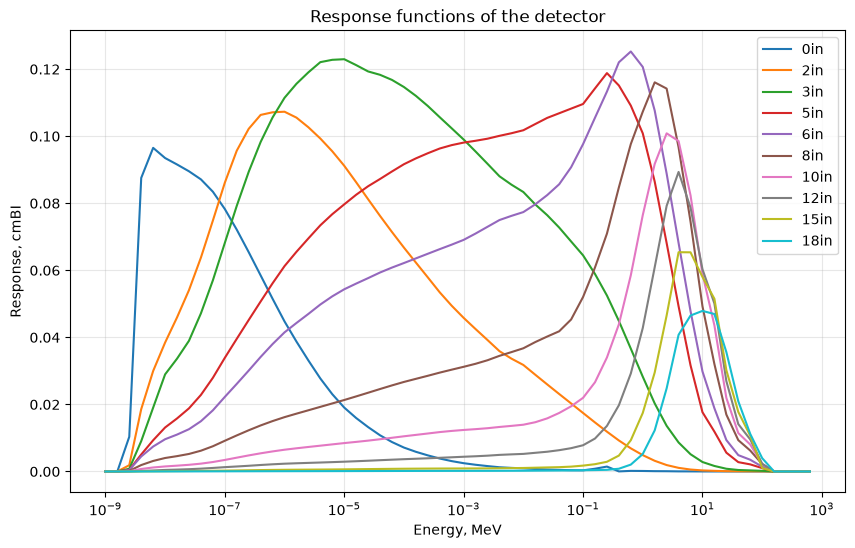

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bssunfold import Detector, RF_GSF
from bssunfold.utils.comparison import compare_spectra

detector = Detector(RF_GSF)
E = detector.E_MeV
names = detector.detector_names
print(f"Detector grid: {detector.n_energy_bins} bins, "
      f"{E[0]:.1e} - {E[-1]:.1f} MeV")
print("Spheres:", ", ".join(names))
detector.plot_response_functions()

## 2. IAEA Compendium reference spectrum -> detector readings

The compendium CSV stores 61-point Monte-Carlo spectra on its own energy
grid, which differs slightly from the 60-bin detector grid, so the
ground truth is interpolated onto the detector grid *for evaluation
only*.  The readings are the spectrum folded with the response
functions.

In [3]:
reference_csv = pd.read_csv(
    '../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv'
)
print(f"Reference CSV: {len(reference_csv)} rows, "
      f"{len(reference_csv.columns) - 1} spectra, "
      f"{reference_csv['E_MeV'].min():.1e} - "
      f"{reference_csv['E_MeV'].max():.0f} MeV")

SPECTRUM = 't4-14-s.txt_1'   # IAEA Compendium BSA benchmark case

readings = detector.get_effective_readings_for_spectra(
    reference_csv[['E_MeV', SPECTRUM]]
)
print("Effective readings:")
for name, val in readings.items():
    print(f"  {name:>4s}: {val:.4f}")

# Interpolate ground truth onto detector grid for evaluation
phi_true = np.interp(
    E, reference_csv['E_MeV'], reference_csv[SPECTRUM]
)

# Active energy bins for plotting
Emax = 20.0
active = E <= Emax
E_active = E[active]
phi_true_active = phi_true[active]

Reference CSV: 61 rows, 20 spectra, 1.0e-09 - 631 MeV
Effective readings:
   0in: 0.0668
   2in: 0.0901
   3in: 0.1382
   5in: 0.1639
   6in: 0.1407
   8in: 0.0805
  10in: 0.0392
  12in: 0.0179
  15in: 0.0064
  18in: 0.0031


## 3. Response-function uncertainty from Monte Carlo

Bonner-sphere response functions carry a few-percent MC uncertainty.
`sensitivity_uncertainties` sets a relative 1σ applied to every
column of the response matrix: $\underline{A} = (1-u) S$,
$\overline{A} = (1+u) S$. Here 5% response uncertainty is combined
with a deliberately wider 10% reading corridor, so the tolerable set
keeps a positive margin (`tol_max > 0`).

In [4]:
result = detector.unfold_interval_matrix(
    readings,
    noise_level=0.10,
    sensitivity_uncertainties=0.05,
    max_neutron_energy=20.0,
    save_result=False,
)
print("method          :", result["method"])
print("functional      :", result["functional"])
print("tol_max         :", f"{result['tol_max']:.6f}")
print("generators      :", result["generators"])
width = np.sum(result["spectrum_upper"] - result["spectrum_lower"])
print(f"total width     : {width:.4f}")
m = compare_spectra(phi_true, result["spectrum"],
                    metrics=["comprehensive_score"])
print(f"score (tol)     : {m['comprehensive_score']:.3f}")

method          : IntervalMatrix
functional      : tol
tol_max         : 0.000154
generators      : [0, 1, 2, 7, 8, 9]
total width     : 46.3786
score (tol)     : 9.364


## 4. Tolerable vs united: quantifier direction matters

$\Xi_{tol}$ demands consistency with *every* matrix in the interval
(pessimistic, safe); $\Xi_{uss}$ needs only *some* matrix
(optimistic). Sweeping the response uncertainty shows the two
diverging: the tolerable hull **shrinks** with $u$ — and collapses to
nothing once $u$ exceeds the reading margin (`tol_max < 0`, the
component bounds return to the empty-set convention) — while the
united hull keeps **growing**. Whenever both are non-empty, the
inclusion $\Xi_{tol} \subseteq \Xi_{uss}$ holds componentwise.

     u    tol_max    width tol    width uss  tol ⊆ uss
    1%   0.000278      52.0265      54.3244       True
    5%   0.000154      46.3786      58.3718       True
   10%  -0.000000      26.4231      62.9039       True
   15%  -0.008195       0.0000      67.4424       True


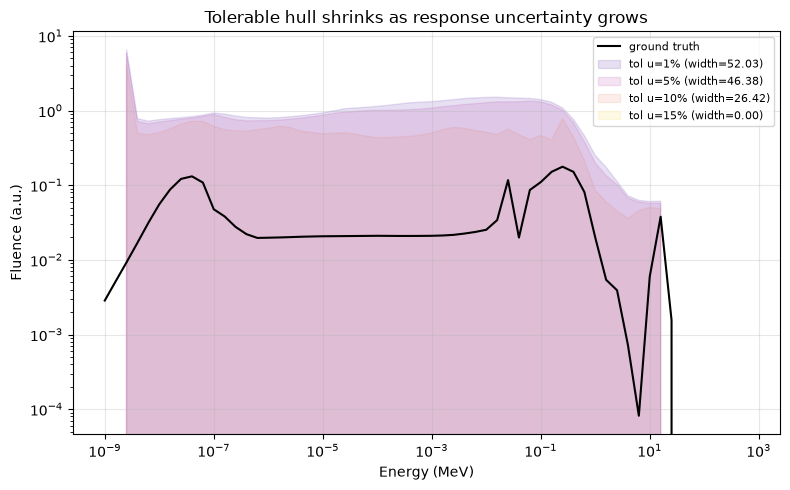

In [5]:
levels = [0.01, 0.05, 0.10, 0.15]

fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(E, phi_true, "k-", lw=1.5, label="ground truth")
colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(levels)))
print(f"{'u':>6s} {'tol_max':>10s} {'width tol':>12s} {'width uss':>12s} "
      f"{'tol ⊆ uss':>10s}")
for color, u in zip(colors, levels):
    tol = detector.unfold_interval_matrix(
        readings, noise_level=0.10, sensitivity_uncertainties=u,
        functional="tol", max_neutron_energy=20.0, save_result=False,
    )
    uss = detector.unfold_interval_matrix(
        readings, noise_level=0.10, sensitivity_uncertainties=u,
        functional="uss", max_neutron_energy=20.0, save_result=False,
    )
    w_tol = np.sum(tol["spectrum_upper"] - tol["spectrum_lower"])
    w_uss = np.sum(uss["spectrum_upper"] - uss["spectrum_lower"])
    inc = bool(
        np.all(tol["spectrum_lower"] >= uss["spectrum_lower"] - 1e-9)
        and np.all(tol["spectrum_upper"] <= uss["spectrum_upper"] + 1e-9)
    )
    ax.fill_between(E, tol["spectrum_lower"], tol["spectrum_upper"],
                    color=color, alpha=0.12,
                    label=f"tol u={u:.0%} (width={w_tol:.2f})")
    print(f"{u:>6.0%} {tol['tol_max']:>10.6f} {w_tol:>12.4f} "
          f"{w_uss:>12.4f} {str(inc):>10}")

ax.set_xlabel("Energy (MeV)")
ax.set_ylabel("Fluence (a.u.)")
ax.set_title("Tolerable hull shrinks as response uncertainty grows")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Degradation check: zero response uncertainty

With `sensitivity_uncertainties=0` the interval matrix collapses to
the point matrix and the bounds must coincide with the classical
`unfold_interval_tol` result — a built-in consistency check of the
Rohn machinery (same reading corridor on both sides).

In [6]:
zero = detector.unfold_interval_matrix(
    readings, noise_level=0.10, sensitivity_uncertainties=0.0,
    max_neutron_energy=20.0, save_result=False,
)
ref = detector.unfold_interval_tol(
    readings, noise_level=0.10, max_neutron_energy=20.0,
    save_result=False,
)
print("bounds agree with point-matrix Tol:",
      np.allclose(zero["spectrum_lower"], ref["spectrum_lower"]),
      np.allclose(zero["spectrum_upper"], ref["spectrum_upper"]))

bounds agree with point-matrix Tol: True True


## 6. X-variativity (SEV)

The interval analysis book proposes a scalar measure of the estimate
uncertainty — the SEV variativity $\sqrt{n}\,K_s\,\mathrm{Tol}^*\,
\|\hat{x}\|_2 / \|b'\|_2$. For the unfolding problem the system is
strongly underdetermined (10 readings, 60 bins), so the reduced
matrix is rank-deficient and SEV is honestly reported as `inf`:
spectrum uncertainty here is governed by the set geometry (the hull)
rather than this conditioning-based scalar. It becomes meaningful for
well-posed square subsystems.

In [7]:
print("SEV (underdetermined unfolding):", result["sev"])
print("inner box available:",
      result["inner_lower"] is not None)

SEV (underdetermined unfolding): inf
inner box available: False


## 7. Inner Khlebnikov box (small problems)

`inner_box=True` computes a guaranteed *inner* interval vector by
maximising the total width over vertex sign combinations
(Hleбников). It is exponential in n, so it runs only for small
systems (n ≤ 10) without TV — on the 60-bin grid it is skipped and
`inner_lower` stays `None`. The demo below shows it on a 2×2
system.

In [8]:
from bssunfold.core.unfold_interval import solve_interval_matrix

A = np.array([[2.0, 1.0], [1.0, 2.0]])
radA = 0.1 * np.abs(A)
A_lo, A_hi = A - radA, A + radA
b_lo = np.array([1.0, 2.0])
b_hi = np.array([2.0, 3.0])
x_min, x_max, info = solve_interval_matrix(A_lo, A_hi, b_lo, b_hi, inner_box=True)
print("tol bounds :", np.round(x_min, 4), np.round(x_max, 4))
print("inner box  :", np.round(info["inner_lower"], 4),
      np.round(info["inner_upper"], 4))
print("inner ⊆ outer:",
      np.all(x_min <= info["inner_lower"]) and
      np.all(info["inner_upper"] <= x_max))

tol bounds : [0.     0.8754] [0.4714 1.3636]
inner box  : [0.     1.1111] [0.303  1.2121]
inner ⊆ outer: True


## 8. Summary

* `unfold_interval_matrix` propagates response-function uncertainty
  through Rohn's componentwise external estimate of the tolerable
  set $\Xi_{tol}$ (and the united set $\Xi_{uss}$).
* `sensitivity_uncertainties` (relative 1σ per sphere or global) or
  explicit `A_lo`/`A_hi`; at zero uncertainty the method reduces to
  the point-matrix Tol bounds exactly.
* Generators (`result["generators"]`) identify the binding
  constraints — outlier detection channels.
* The Khlebnikov inner box and SEV variativity are provided where
  mathematically meaningful (small n, full-rank), and honestly marked
  as unavailable otherwise.